In [90]:
import os, glob, pickle, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn.plotting import plot_glass_brain
from tqdm import tqdm

ROOT = '/Volumes/shohamy-locker/jonathan/fifo/fifo_mri'
BETA_DIR = os.path.join(ROOT, 'derivatives', 'betaseries')
BEH_EVENT_DIR = '/Users/chrisiyer/_Current/lab/code/fan-color/fifo_mri/from_jonathan/capsule-0625246-event_files_IMG'
BEH_AGG_DIR = '/Users/chrisiyer/_Current/lab/code/fan-color/fifo_mri/from_jonathan/capsule-0625246-behavior'
CLASSIFIER_DATA_FILE = os.path.join(ROOT, 'scripts/model_fits/category_probabilities.csv')

# Data processing

In [98]:
condition_mapper = pd.read_csv('from_jonathan/fulL_paired_id_mapper.csv',index_col=0)
condition_mapper['condition_simple'] = condition_mapper['condition'].str.split('_').str[0] # 'fanin' vs. 'fanout'

# get behavioral data, concatenating runs 1 and 2
def get_beh_data(sub_num, task='assoc'):
    sub_str = f"sub-{sub_num:02d}"
    sub_beh_dir = os.path.join(BEH_EVENT_DIR, sub_str, 'func')
    if task == 'choice':
        beh = pd.read_csv(os.path.join(sub_beh_dir, f'{sub_str}_ses-fifo_task-{task}_run-1_events.tsv'), sep='\t')
        return beh.drop(columns=['onset','duration'])
        
    rundata = []
    for run in [1,2]:
        rundata.append(pd.read_csv(
            os.path.join(sub_beh_dir, f'{sub_str}_ses-fifo_task-{task}_run-{run}_events.tsv'),
            sep='\t'
        ))
    beh = pd.concat(rundata).reset_index(drop=True)

    if task == 'rew':
        return beh.drop(columns=['onset','duration'])

    # add condition column (fanin vs. fanout)
    sub_mapper = condition_mapper[condition_mapper.subject_id==sub_str]
    beh = beh.merge(sub_mapper[['image', 'condition_simple', 'img_type']],
                    left_on='trial_type', right_on='image', how='left')
    beh['condition'] = beh['condition_simple']

    # add stim_typle column - A or B item (C in the mapper)
    beh['stim_type'] = None
    beh.loc[beh.img_type.str.startswith('A', na=False), 'stim_type'] = 'A'
    beh.loc[beh.img_type.str.startswith('C', na=False), 'stim_type'] = 'B'

    # add pair_to_compare column 
    # fanin A items will be compared to their pairmate
    # fanout B items compared to their pairmate 
    # fanout A and fanin B items will be compared to the one with same ID
    pair_map = {}
    for i,r in sub_mapper.iterrows():
        if r.paired1!='none' and r.paired2!='none': # this covers fanin A and fanout B
            pair_map[r.paired1] = r.paired2
            pair_map[r.paired2] = r.paired1
        else:
            if r.paired1 != 'none':
                id_to_find = r.paired1
            else: 
                id_to_find = r.paired2
            id_type = sub_mapper[sub_mapper.image == id_to_find].img_type.iloc[0]
            id_of_type_match = sub_mapper[(sub_mapper.image != id_to_find) & (sub_mapper.img_type == id_type)].image.iloc[0]
            pair_map[id_to_find] = id_of_type_match
    beh['pair_to_compare'] = beh['trial_type'].map(pair_map)
    beh['category'] = [b[:-1] for b in beh['trial_type']]
    beh['repetition'] = beh.groupby('trial_type').cumcount() + 1

    return beh.drop(columns=['image', 'condition_simple', 'img_type', 'onset', 'duration', 'correct', 'response_time'])
    


# get hippocampal mask from the fMRIPrep outputs
def get_hipp_mask(sub_num):
    sub_str = f"sub-{sub_num:02d}"
    path = os.path.join(
        ROOT, 'derivatives', 'fmriprep', sub_str, 'ses-fifo', 'func',
        f'{sub_str}_ses-fifo_task-assoc_run-1_space-MNI152NLin2009cAsym_desc-aparcaseg_dseg.nii.gz'
    )
    aparcaseg = nib.load(path)
    aparcaseg_data = aparcaseg.get_fdata()
    hippo_data = np.isin(aparcaseg_data, [17, 53]).astype(float)
    hippo_img = nib.Nifti1Image(hippo_data, aparcaseg.affine)
    return hippo_img


def extract_roi(img_path, mask_img):
    img = nib.load(img_path)
    img_data = img.get_fdata()
    mask_data = mask_img.get_fdata() == 1
    roi_data = img_data[mask_data]
    return roi_data


# extract hippocampal patterns from NIBS series
def beta_data_helper(sub_num, task='assoc'):
    sub_str = f"sub-{sub_num:02d}"
    sub_beta_dir = os.path.join(BETA_DIR, task, 'nibetaseries', sub_str, 'ses-fifo', 'func')
    hipp_mask = get_hipp_mask(sub_num)
    output = {'face': [], 'scene': [], 'tool': []}
    
    for stim_type in ['face','scene','tool']:
        run1_path = os.path.join(sub_beta_dir, f'{sub_str}_ses-fifo_task-{task}_run-1_space-MNI152NLin2009cAsym_desc-{stim_type}_betaseries.nii.gz')
        run2_path = os.path.join(sub_beta_dir, f'{sub_str}_ses-fifo_task-{task}_run-2_space-MNI152NLin2009cAsym_desc-{stim_type}_betaseries.nii.gz')
        
        arrs = []
        if os.path.exists(run1_path): arrs.append(extract_roi(run1_path, hipp_mask))
        if os.path.exists(run2_path): arrs.append(extract_roi(run2_path, hipp_mask))
            
        if arrs:
            # Safely handle single 1D betas (e.g. only 1 trial per condition run)
            if len(arrs[0].shape) == 1: 
                arrs = [a.reshape(-1, 1) for a in arrs]
            output[stim_type] = np.concatenate(arrs, axis=1)
            
    return output


# reorder beta data to match the behavioral data flexibly across tasks
def get_beta_data(sub_num, task='assoc'):
    beh = get_beh_data(sub_num, task) 
    beta_data_bystim = beta_data_helper(sub_num, task=task) 

    example_key = [k for k in beta_data_bystim if len(beta_data_bystim[k]) > 0][0]
    n_voxels = beta_data_bystim[example_key].shape[0]
    n_trials = len(beh)
    ordered_betas = np.zeros((n_trials, n_voxels))

    # Track the next available volume index for each category pointer
    pointers = {'face': 0, 'scene': 0, 'tool': 0}
    
    for i, row in beh.iterrows():
        # Get category label by stripping trailing numbers flexibly across single/paired arrays (e.g., 'face3' -> 'face' or 'face5face2' -> 'faceface')
        category = ''.join([char for char in str(row['trial_type']) if not char.isdigit()])
        
        # A quick fix for transferring paired Choice trails to single base categories 
        # (e.g. 'face4face3' => 'faceface' => 'face')
        if category in ['faceface', 'scenescene', 'tooltool']:
            category = category[:4] if category.startswith('face') else (category[:5] if category.startswith('scene') else category[:4])
            
        # Extract identically aligned voxel array map
        trial_idx = pointers[category]
        ordered_betas[i, :] = beta_data_bystim[category][:, trial_idx]
        pointers[category] += 1
        
    return ordered_betas


def extract_all_hipp_data(task='assoc'):
    output = {}
    print(f"Extracting hippocampal pattern betas for {task} phase...")
    for sub in tqdm(range(1, 41)):
        # Safely exclude subject 27 from the start
        # if sub == 27: continue
        betas = get_beta_data(sub, task=task)
        output[sub] = betas
            
    # Safely save with the explicit phase naming standard 
    # (e.g. hipp_patterns_rew.pkl, hipp_patterns_choice.pkl, etc)
    save_path = f'/Users/chrisiyer/_Current/lab/code/fan-color/fifo_mri/hipp_patterns_{task}.pkl'
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    with open(save_path, 'wb') as f:
        pickle.dump(output, f)
    print(f"Saved successfully to {save_path}")

def load_all_hipp_data(task='assoc'):
    load_path = f'/Users/chrisiyer/_Current/lab/code/fan-color/fifo_mri/hipp_patterns_{task}.pkl'
    with open(load_path, 'rb') as f:
        return pickle.load(f)

# extract_all_hipp_data(task='assoc')
# extract_all_hipp_data(task='rew')

In [94]:
hipp_patterns = load_all_hipp_data()

# Repulsion Analysis

how do item representations of overlapping vs. non-overlapping items change over the course of learning?

We'll focus on the fan-in A items (both associated with the same B) and the fan-out B items (both associated with the same A). We'll compute the hippocampal pattern similarity of these "shared-node" pairs over the 5 repetitions during training that the pairs are shown. Note that the two items in these pairs are always a different image category (e.g. a face and a scene). 

So, as a baseline, we'll compare against the pattern similarity of all pairs with the same categories and types. For instance, say that A1 is a face and A2 is a scene, both associated with a tool B1. We will compute the A1-A2 pattern similarity ("fanin_A"). Then we will compute the average similarity of A1 to all other scenes (A5, A8, A11) and A2 to all other faces (A4, A7, A10). These do not share a node, but should have the same expected similarity from visual stuff alone. Then we'll do the same for each fan-in A pair, and each fan-out B pair.

We can visualize these in relation to their baseline, or as a difference.

In [99]:
# hypothesis: fan-in A items and fan-out B items will be 
# first integrated then repulsed over the course of training 

sim_data = pd.DataFrame(columns=['sub','condition','repetition','mean_corr']) # mean similarity across items at each repetition
rep5_data = [] # for each pair, also store the data from just the 5th/final repetition

for sub in range(1,41):
    beh = get_beh_data(sub)
    # Filter to unique pairs where a partner exists
    unique_pairs = np.unique([sorted((r.trial_type, r.pair_to_compare)) for _,r in beh.iterrows() 
                             if pd.notna(r.pair_to_compare)], axis=0)
    z_matrix = np.arctanh(np.clip(np.corrcoef(hipp_patterns[sub]), -0.99, 0.99))

    
    for repetition in range(1,6):
        rep_similarities = {
            'fanin_A': [], 'fanin_A_baseline': [], 'fanin_A_minus_baseline': [],
            'fanout_B': [], 'fanout_B_baseline': [], 'fanout_B_minus_baseline': [],
        }
        beh_rep = beh[beh.repetition==repetition]
        idx_map = {row.trial_type: idx for idx, row in beh_rep.iterrows()} # each trial_type only 1x per reptition; this just speeds up

        for img1, img2 in unique_pairs:
            idx1, idx2 = idx_map[img1], idx_map[img2]
            row1, row2 = beh_rep.loc[idx1], beh_rep.loc[idx2]

            condition = row1.condition + '_' + row1.stim_type # fanin_A
            if condition in ['fanin_A', 'fanout_B']:
                # store pair similarity
                pair_corr_z = z_matrix[idx1, idx2]

                # now compute baseline: A1 with other A items of category A2, A2 with other A items category A1; same for B
                # start by just getting same type (A/B) and condition (fanin/out)--e.g., all fanin A items
                peers = beh_rep[(beh_rep.condition == row1.condition) & (beh_rep.stim_type == row1.stim_type)]
                # now get all the ones that share a category, and aren't the one we're already comparing
                cat1_peers = peers[(peers.category == row1.category) & (peers.trial_type != img1)]
                cat2_peers = peers[(peers.category == row2.category) & (peers.trial_type != img2)]

                # now compute all pairwise corrs and average
                baseline_corrs = []
                baseline_corrs.extend(z_matrix[idx1, cat2_peers.index])
                baseline_corrs.extend(z_matrix[idx2, cat1_peers.index])
                baseline_mean = np.mean(baseline_corrs)

                rep_similarities[condition].append(pair_corr_z)
                rep_similarities[condition + '_baseline'].append(baseline_mean)
                rep_similarities[condition + '_minus_baseline'].append(pair_corr_z - baseline_mean)

                # 2. SAVE THE INDIVIDUAL PAIR DATA (Only for the 5th occurrence, as requested)
                if repetition == 5:
                    rep5_data.append({
                        'sub': sub,
                        'condition': condition,
                        'img1': img1,
                        'img2': img2,
                        'similarity': pair_corr_z,
                        'relative_similarity': pair_corr_z - baseline_mean
                    })

        for cond, vals in rep_similarities.items():
            sim_data.loc[len(sim_data)] = [sub, cond, repetition, np.mean(vals)]

rep5_data = pd.DataFrame(rep5_data)

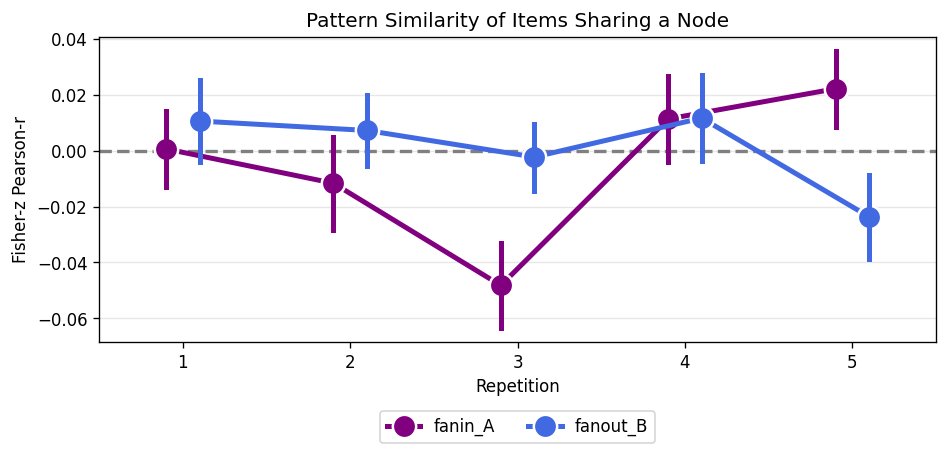

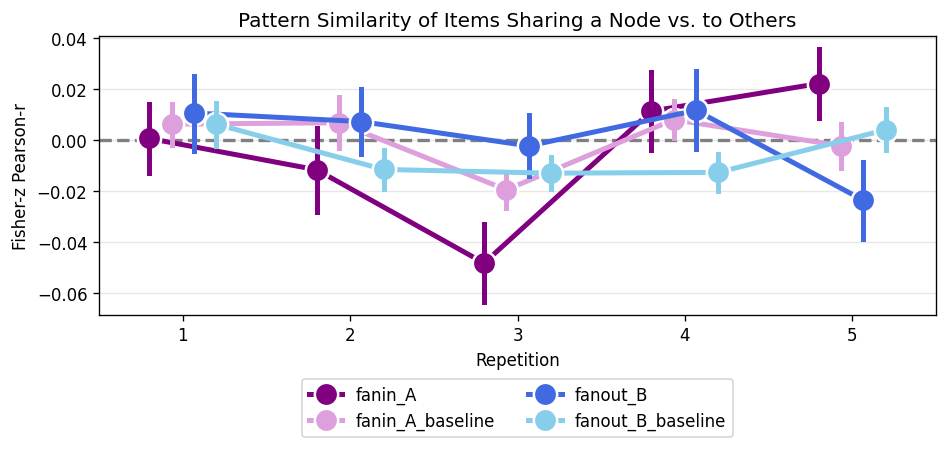

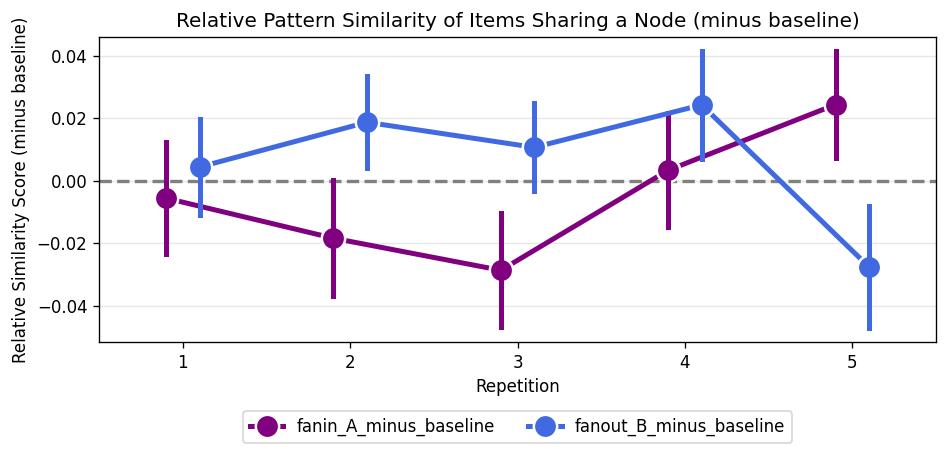

In [100]:
def plot_similarity(df, conditions, palette, title, ylabel="Fisher-z Pearson-r"):
    plt.figure(figsize=(8,4), dpi=120)
    plt.title(title)
    plt.xlabel("Repetition")
    plt.ylabel(ylabel)
    plt.hlines(0, xmin=-0.5, xmax=4.5, color='gray', linestyle='--', linewidth=2)
    
    # Filter data to only requested conditions
    plot_df = df[df.condition.isin(conditions)]
    
    ax = sns.pointplot(
        data=plot_df, 
        x='repetition', 
        y='mean_corr',
        hue='condition', 
        hue_order=conditions, # Keeps legend order consistent with palette
        errorbar='se',
        dodge=0.1 * len(plot_df.condition.unique()),
        linewidth=3,
        markersize=14,
        markeredgecolor='white', 
        markeredgewidth=1.5,    
        err_kws={'linewidth': 3},
        palette=palette
    )
    
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=True)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    return ax

# 1. Overlap Pairs Only
plot_similarity(
    sim_data, 
    conditions=['fanin_A', 'fanout_B'],
    palette=['purple', 'royalblue'],
    title='Pattern Similarity of Items Sharing a Node'
)
plt.savefig('plots/plot_overlap_pairs_only.png')
plt.show()

# 2. Overlaps + Baselines
plot_similarity(
    sim_data, 
    conditions=['fanin_A', 'fanin_A_baseline', 'fanout_B', 'fanout_B_baseline'],
    palette=['purple', 'plum', 'royalblue', 'skyblue'],
    title='Pattern Similarity of Items Sharing a Node vs. to Others'
)
plt.savefig('plots/plot_overlap_pairs_and_baselines.png')
plt.show()

# 3. Difference Scores (Pair Advantage)
plot_similarity(
    sim_data, 
    conditions=['fanin_A_minus_baseline', 'fanout_B_minus_baseline'],
    palette=['purple', 'royalblue'],
    title='Relative Pattern Similarity of Items Sharing a Node (minus baseline)',
    ylabel='Relative Similarity Score (minus baseline)'
)
plt.savefig('plots/plot_overlap_pair_diff.png')
plt.show()


# Relate to decision behavior & reactivation


In [101]:
# helpers
def extract_cat(item_name): # extract category ("scene") from stimulus ID ("scene5")
    if not isinstance(item_name, str) or item_name == 'none': return None
    match = re.match(r'([a-zA-Z]+)', item_name)
    return match.group(1) if match else None

classifier_df = pd.read_csv(CLASSIFIER_DATA_FILE)

# pre-load all pairwise similarities (for fanin A and fanout B) from rep5_data 
img_to_sim = {}
img_to_rel_sim = {}
img_to_cond = {}
for _, row in rep5_data.iterrows():
    sub_str = f"sub-{int(row['sub']):02d}"
    k1 = (sub_str, row.img1); k2 = (sub_str, row.img2)
    img_to_sim[k1] = row.similarity
    img_to_sim[k2] = row.similarity
    img_to_rel_sim[k1] = row.relative_similarity
    img_to_rel_sim[k2] = row.relative_similarity
    img_to_cond[k1] = row.condition
    img_to_cond[k2] = row.condition

In [102]:
# ==============================================================================
# REWARD PHASE (Proactive Reactivation) 
# ==============================================================================
all_reward_trials = []

for sub_id in range(1, 41):
    if sub_id==27:
        continue

    sub_str = f"sub-{sub_id:02d}"
    rew_data = get_beh_data(sub_id, 'rew')
    rew_stim = rew_data[~rew_data['trial_type'].isin(['reward', 'no_reward'])].reset_index(drop=True)
    c_rew = classifier_df[(classifier_df.sub_id == sub_str) & (classifier_df.task == 'rew')].reset_index(drop=True)
    merged_rew = pd.concat([rew_stim, c_rew[['probability_face', 'probability_scene', 'probability_tool']]], axis=1)
    
    for _, row in merged_rew.iterrows():
        b_item = row['trial_type']
        a1_name = row['paired_type1']
        a2_name = row['paired_type2']

        # FAN-OUT B Items (B item is paired with one A item)
        if a2_name == 'none':
            cat_a1 = extract_cat(a1_name)
            prob_a1 = row[f'probability_{cat_a1}'] # classifier evidence for A item category

            sim_score = img_to_sim[(sub_str, b_item)] # similarity of B to its fan-out pair (share the same A)
            rel_sim_score = img_to_rel_sim[(sub_str, b_item)]
            
            all_reward_trials.append({
                'sub_num': sub_id, 'sub_id': sub_str,
                'condition': 'fanout_B',
                'b_item': b_item,
                'rew_reactivation': prob_a1,  # Target A-item evidence
                'pair_similarity': sim_score, # B2-B3 similarity
                'pair_relative_similarity': rel_sim_score
            })
        
        # FAN-IN A Items (B item is paired with two A items)
        else:
            cat_a1 = extract_cat(a1_name)
            cat_a2 = extract_cat(a2_name)
            prob_a1 = row[f'probability_{cat_a1}']
            prob_a2 = row[f'probability_{cat_a2}']
            # AVERAGE the evidence of the two A-categories (this is hacky but whatever)
            avg_a_reactivation = (prob_a1 + prob_a2) / 2.0 
            
            sim_score = img_to_sim[(sub_str, a1_name)] # similarity of A to its fan-in pair (share the same B)
            rel_sim_score = img_to_rel_sim[(sub_str, a1_name)]
            
            all_reward_trials.append({
                'sub_num': sub_id, 'sub_id': sub_str,
                'condition': 'fanin_A',
                'b_item': b_item,
                'rew_reactivation': avg_a_reactivation,
                'pair_similarity': sim_score,
                'pair_relative_similarity': rel_sim_score
            })
            
reward_react_df = pd.DataFrame(all_reward_trials)

# now average the reactivation evidence across the 10 trials that a given B item was rewarded
reward_react_agg = reward_react_df.groupby(['sub_num', 'sub_id', 'condition', 'b_item']).agg(
    rew_reactivation_avg=('rew_reactivation', 'mean'),
    pair_similarity=('pair_similarity', 'first'),
    pair_relative_similarity=('pair_relative_similarity', 'first')
).reset_index()

reward_react_agg.to_csv('rdata_reward.csv', index=False)


In [103]:
# ==============================================================================
# 2. Extract RT, Reactivation, and Pattern Mapping per Decision Frame
# ==============================================================================
choice_data = []

for sub_id in range(1, 41):
    if sub_id == 27: continue
    sub_str = f'sub-{sub_id:02d}'
    
    choice_beh = get_beh_data(sub_id, 'choice').dropna(subset=['trial_type', 'response_time']).reset_index(drop=True)
    c_choice = classifier_df[(classifier_df.sub_id == sub_str) & (classifier_df.task == 'choice')].reset_index(drop=True)
    
    if len(choice_beh) != len(c_choice): continue
        
    merged_choice = pd.concat([choice_beh, c_choice[['probability_face', 'probability_scene', 'probability_tool']]], axis=1)
        
    for _, row in merged_choice.iterrows():
        
        # Guard against arbitrary ITI padding intervals
        if not isinstance(row['trial_type'], str): continue
        m = re.match(r'([a-zA-Z]+[0-9]+)([a-zA-Z]+[0-9]+)', row['trial_type'])
        if not m: continue
            
        img1_str, img2_str = m.group(1), m.group(2)
        
        # Safely identify if this is an A (Transfer) or B (Test) trial
        base_cond = img_to_cond.get((sub_str, img1_str)) 
        
        # If it wasn't a Test pair in rep5, it is a Transfer trial! Let's deduce if it's Fan-in or Fan-out.
        if base_cond is None and (sub_str, img1_str) in a_info:
            base_cond = a_info[(sub_str, img1_str)]['cond']
            
        # -------- REACTIVATION SCORES (transfer trials only) --------
        a_cat = extract_cat(img1_str) 
        react_score = np.nan
        
        if base_cond in ['fanin_A', 'fanout_A']:
            a1_info = a_info.get((sub_str, img1_str))
            b_cat = a1_info['b_cat']
            
            if base_cond == 'fanin_A':
                # Fan-in trials: reactivation of the single identical B category
                react_score = row.get(f'probability_{b_cat}')
            else: 
                # Fan-out trials: A produces two B's; reactivation is diff(rewarded_B - unrewarded_unshown_C)
                evidence_b = row.get(f'probability_{b_cat}')
                other_b_cat = [c for c in ['face', 'scene', 'tool'] if c not in [a_cat, b_cat]][0]
                evidence_other_b = row.get(f'probability_{other_b_cat}')
                
                if evidence_b is not None and evidence_other_b is not None:
                    react_score = evidence_b - evidence_other_b
        
        # -------- PATTERN SIMILARITY (all trials) --------
        if base_cond == 'fanout_A':
            # Fan-Out TRANSFER: Look up and average the nested paired B-items similarity scores!
            b_item1 = a_info[(sub_str, img1_str)]['b_item']
            b_item2 = a_info[(sub_str, img2_str)]['b_item']
            
            sim_1 = img_to_sim.get((sub_str, b_item1), np.nan)
            sim_2 = img_to_sim.get((sub_str, b_item2), np.nan)
            rel_sim_1 = img_to_rel_sim.get((sub_str, b_item1), np.nan)
            rel_sim_2 = img_to_rel_sim.get((sub_str, b_item2), np.nan)
        else:
            # Fan-In TRANSFER & Fan-Out TEST: Images exactly match rep5 keys!
            sim_1 = img_to_sim.get((sub_str, img1_str), np.nan)
            sim_2 = img_to_sim.get((sub_str, img2_str), np.nan)
            rel_sim_1 = img_to_rel_sim.get((sub_str, img1_str), np.nan)
            rel_sim_2 = img_to_rel_sim.get((sub_str, img2_str), np.nan)

        avg_pair_sim = (sim_1 + sim_2) / 2.0
        avg_rel_pair_sim = (rel_sim_1 + rel_sim_2) / 2.0

        choice_data.append({
            'sub_id': sub_str, 
            'trial_type': row['trial_type'],
            'img1': img1_str, 
            'img2': img2_str, 
            'rt': row['response_time'],
            'item_condition': base_cond,
            'choice_reactivation': react_score,
            'avg_pair_sim': avg_pair_sim,
            'avg_rel_pair_sim': avg_rel_pair_sim
        })

choice_df = pd.DataFrame(choice_data)

# Average across the distinct repeated test frames for identical image pairs 
choice_df_agg = choice_df.groupby(['sub_id', 'item_condition', 'trial_type', 'img1', 'img2']).agg(
    choice_rt_avg=('rt', 'mean'),
    choice_react_avg=('choice_reactivation', 'mean'),
    avg_pair_sim=('avg_pair_sim', 'first'),       
    avg_relative_similarity=('avg_rel_pair_sim', 'first') 
).reset_index()

# Extract behavioral metrics identically as before
beh_by_item = pd.read_csv(os.path.join(BEH_AGG_DIR, 'choices_by_image.csv'), index_col=0)
choice_df = pd.merge(beh_by_item, choice_df_agg, on=['sub_id', 'trial_type', 'img1', 'img2'], how='inner')
choice_df['choice_rt_avg_log'] = np.log(choice_df['choice_rt_avg'])
choice_df.to_csv('rdata_choice.csv', index=False)

### Decision behavior

The more A1 and A2 are decorrelated, do you see better transfer decisions (averaged over A1 and A2 decisions)? Specifically, if a decision is over A1 vs. A4, are you more likely to be correct if A1/A2 and A4/A5 are more separated during initial learning?

The more B2 and B3 are decorrelated, do you see better test decisions? Specifically, is a decision is over B2 vs. B5, are you more likely to respond correctly if B2/B3 and B5/B6 were more separated during initial learning?

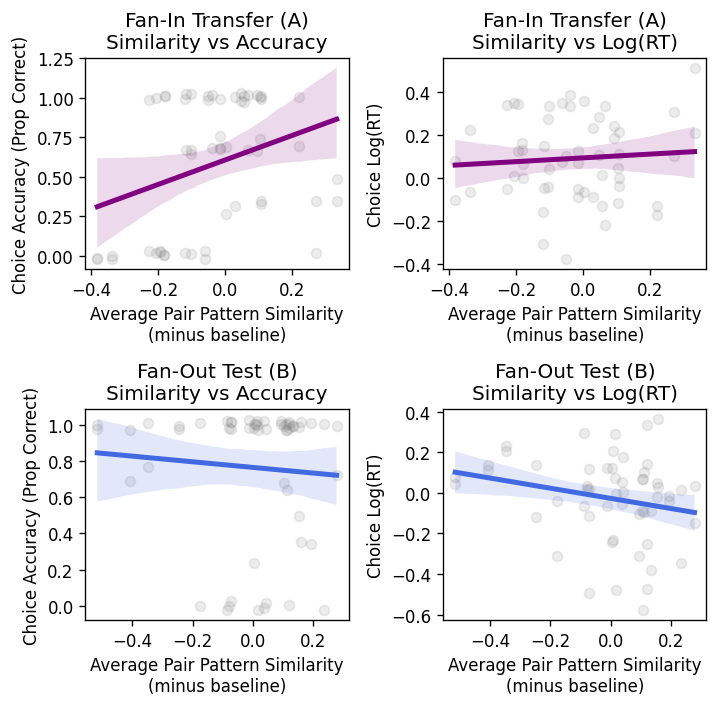

In [104]:
plt.figure(figsize=(6, 6), dpi=120)

for i, cond in enumerate(['fanin_A', 'fanout_B']):
    subset = choice_df[choice_df['item_condition'] == cond]
    title_prefix = "Fan-In Transfer (A)" if cond == 'fanin_A' else "Fan-Out Test (B)"
    color = "purple" if cond == "fanin_A" else "royalblue"
    
    # 1. Similarity vs Accuracy
    ax1 = plt.subplot(2, 2, i*2 + 1)
    sns.regplot(data=subset, x='avg_relative_similarity', y='correct', 
                y_jitter=0.03, ax=ax1,
                scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': color, 'linewidth': 3})
    ax1.set_title(f"{title_prefix}\nSimilarity vs Accuracy")
    ax1.set_ylabel("Choice Accuracy (Prop Correct)")
    ax1.set_xlabel("Average Pair Pattern Similarity\n(minus baseline)")
    
    # 2. Similarity vs Log RT
    ax2 = plt.subplot(2, 2, i*2 + 2)
    sns.regplot(data=subset, x='avg_relative_similarity', y='choice_rt_avg_log', 
                ax=ax2,
                scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': color, 'linewidth': 3})
    ax2.set_title(f"{title_prefix}\nSimilarity vs Log(RT)")
    ax2.set_ylabel("Choice Log(RT)")
    ax2.set_xlabel("Average Pair Pattern Similarity\n(minus baseline)")

plt.tight_layout()
plt.savefig('plots/plot_similarity_decision.png')
plt.show()

In [ ]:
# STATISTICS ARE DONE IN R

### Reactivation

1. The more A1 and A2 are decorrelated, are you more/less likely to get reward-phase (proactive) reactivation? Average category evidence of A1 category and A2 category. In general the fan-in condition has less reward-phase reactivation than the fan-out. But does it vary for trials of more/less decorrelated A items.

2. Also, relate A1-A2 similarity to B category reactivation during decisions (reactive inference). This one is weird because for a pair of A items, you have two different pattern similarity measures (one for each of the choice options). We'll have to just average them, and hope we get enough variance from both being high or both being low. 

3. The more B2 and B3 are decorrelated, are you more/less likely to reactivate A3 during B reward learning (proactive)? This is the cleanest analysis, but not as theoretically interesting.

4. Also relate B2-B3 similarity to reactive reactivation during A3-A6 transfer decisions? Once again we have two similarity measures per trial, we'll have to average which is not ideal. But at least the reactivation measure is more clear: the classifier evidence for the rewarded (or non-rewarded) B category minus the evidence for the B category that didn't occur during reward learning.

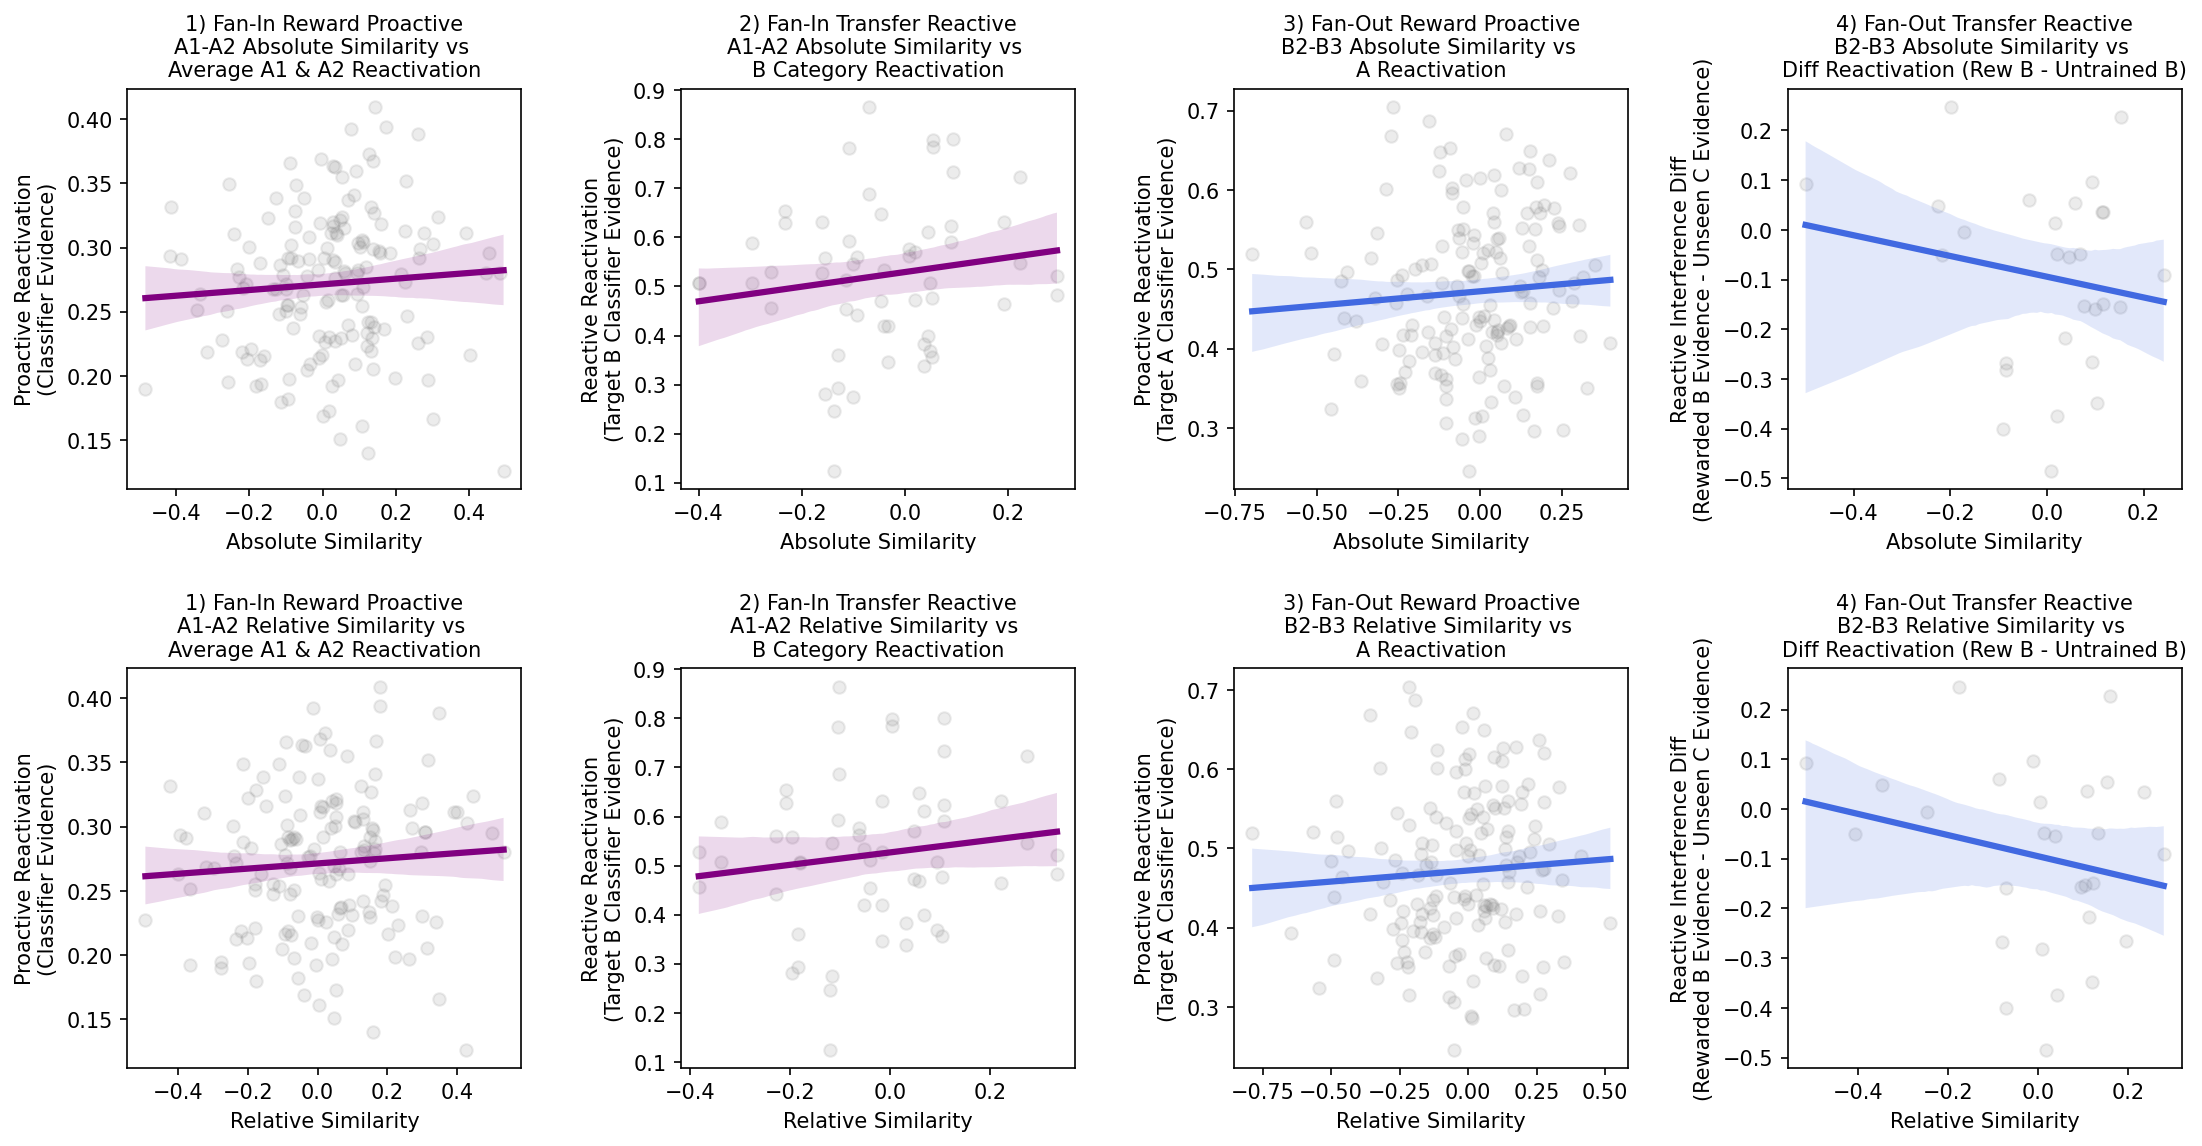

In [105]:
# Load dataframes precisely as exported
rew_df = pd.read_csv('rdata_reward.csv')
choice_df = pd.read_csv('rdata_choice.csv')

# Drop missing values
rew_df = rew_df.dropna(subset=['pair_similarity', 'rew_reactivation_avg'])
choice_df = choice_df.dropna(subset=['avg_pair_sim', 'choice_react_avg'])

plt.figure(figsize=(15, 8), dpi=150)

metrics = [
    ('pair_similarity', 'avg_pair_sim', 'Absolute Similarity'),
    ('pair_relative_similarity', 'avg_relative_similarity', 'Relative Similarity')
]

plot_idx = 1
for metric_rew, metric_choice, metric_name in metrics:
    # --------------------------------------------------------------------------
    # Plot 1: FAN-IN PROACTIVE REACTIVATION (Hypothesis 1)
    # --------------------------------------------------------------------------
    ax1 = plt.subplot(2, 4, plot_idx)
    subset_1 = rew_df[rew_df['condition'] == 'fanin_A']
    sns.regplot(data=subset_1, x=metric_rew, y='rew_reactivation_avg', 
                ax=ax1, scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': 'purple', 'linewidth': 3})
    ax1.set_title(f"1) Fan-In Reward Proactive\nA1-A2 {metric_name} vs \nAverage A1 & A2 Reactivation", fontsize=10)
    ax1.set_ylabel("Proactive Reactivation\n(Classifier Evidence)")
    ax1.set_xlabel(metric_name)
    
    # --------------------------------------------------------------------------
    # Plot 2: FAN-IN REACTIVE INFERENCE (Hypothesis 2)
    # --------------------------------------------------------------------------
    ax2 = plt.subplot(2, 4, plot_idx + 1)
    subset_2 = choice_df[choice_df['item_condition'] == 'fanin_A']
    sns.regplot(data=subset_2, x=metric_choice, y='choice_react_avg', 
                ax=ax2, scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': 'purple', 'linewidth': 3})
    ax2.set_title(f"2) Fan-In Transfer Reactive\nA1-A2 {metric_name} vs \nB Category Reactivation", fontsize=10)
    ax2.set_ylabel("Reactive Reactivation\n(Target B Classifier Evidence)")
    ax2.set_xlabel(metric_name)

    # --------------------------------------------------------------------------
    # Plot 3: FAN-OUT PROACTIVE REACTIVATION (Hypothesis 3)
    # --------------------------------------------------------------------------
    ax3 = plt.subplot(2, 4, plot_idx + 2)
    subset_3 = rew_df[rew_df['condition'] == 'fanout_B']
    sns.regplot(data=subset_3, x=metric_rew, y='rew_reactivation_avg', 
                ax=ax3, scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': 'royalblue', 'linewidth': 3})
    ax3.set_title(f"3) Fan-Out Reward Proactive\nB2-B3 {metric_name} vs \nA Reactivation", fontsize=10)
    ax3.set_ylabel("Proactive Reactivation\n(Target A Classifier Evidence)")
    ax3.set_xlabel(metric_name)

    # --------------------------------------------------------------------------
    # Plot 4: FAN-OUT REACTIVE INFERENCE (Hypothesis 4)
    # --------------------------------------------------------------------------
    ax4 = plt.subplot(2, 4, plot_idx + 3)
    subset_4 = choice_df[choice_df['item_condition'] == 'fanout_A']
    sns.regplot(data=subset_4, x=metric_choice, y='choice_react_avg', 
                ax=ax4, scatter_kws={'alpha': 0.15, 'color': 'gray'},
                line_kws={'color': 'royalblue', 'linewidth': 3})
    ax4.set_title(f"4) Fan-Out Transfer Reactive\nB2-B3 {metric_name} vs \nDiff Reactivation (Rew B - Untrained B)", fontsize=10)
    ax4.set_ylabel("Reactive Interference Diff\n(Rewarded B Evidence - Unseen C Evidence)")
    ax4.set_xlabel(metric_name)
    
    plot_idx += 4

plt.tight_layout(pad=2.0)
plt.savefig('plots/plot_similarity_reactivation.png')
plt.show()

In [ ]:
# STATISTICS ARE DONE IN R

# B-item representational change in reward learning phase

As you learn B2->$, does it become further and further from B3?

In [110]:
def get_raw_beh(sub_num, task):
    sub_str = f"sub-{sub_num:02d}"
    fs = sorted(glob.glob(f"{BEH_EVENT_DIR}/{sub_str}/func/*{task}_run-*_events.tsv"))
    if not fs: return pd.DataFrame()
    return pd.concat([pd.read_csv(f, sep='\t') for f in fs], ignore_index=True)

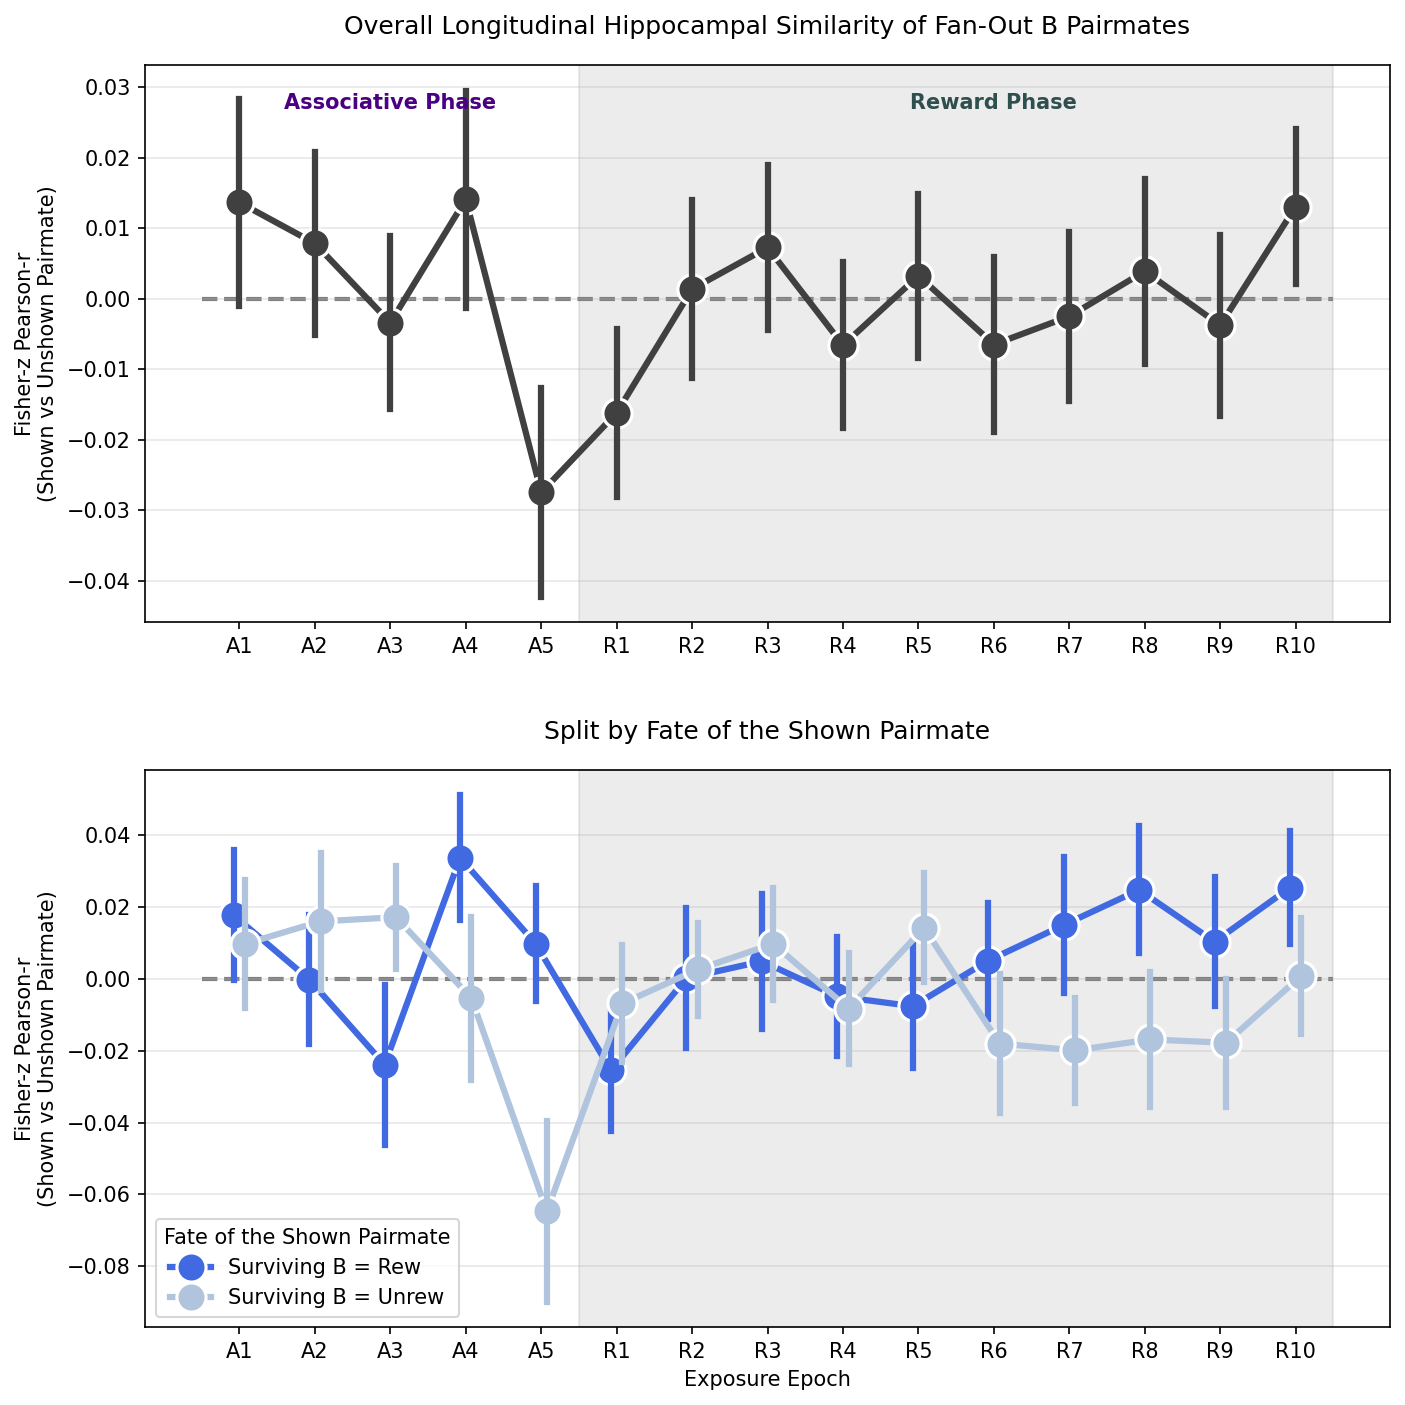

In [120]:
assoc_data = load_all_hipp_data('assoc')
rew_data = load_all_hipp_data('rew')

all_sims = []

# ------------------------------------------------------------------------------
# GENERATE LONGITUDINAL TRAJECTORIES
# ------------------------------------------------------------------------------
for sub_id in assoc_data.keys():
    if sub_id not in rew_data: continue
    
    assoc_betas = assoc_data[sub_id]
    rew_betas = rew_data[sub_id]
    sub_str = f"sub-{sub_id:02d}"
    
    df_assoc = get_raw_beh(sub_id, 'assoc')
    df_rew = get_raw_beh(sub_id, 'rew')
    stims_assoc = df_assoc
    stims_assoc['idx'] = np.arange(len(stims_assoc))
        
    # Identify Fan-Out pairs from Assoc phase seamlessly
    # Fan-Out A items are those `paired_type` which map to exactly 2 `trial_type` items
    pairs_A = df_assoc.groupby('paired_type')['trial_type'].unique()
    fanout_pairs = pairs_A[pairs_A.apply(len) == 2]
    
    # Construct Reward Mapping for later splits
    item_to_reward = {}
    for i in range(len(df_rew) - 1):
        if df_rew.loc[i, 'trial_type'] not in ['reward', 'no_reward']:
            nxt = df_rew.loc[i+1, 'trial_type']
            item_to_reward[df_rew.loc[i, 'trial_type']] = 'Rew' if nxt == 'reward' else 'Unrew'
        
    # Strip reward fixations to perfectly align trailing indices  
    stims_rew = df_rew[~df_rew['trial_type'].isin(['reward', 'no_reward'])].copy().reset_index(drop=True)
    stims_rew['idx'] = np.arange(len(stims_rew))
    
    for a_item, b_items in fanout_pairs.items():
        b1, b2 = b_items[0], b_items[1]
        
        # Which pairmate survived into the reward phase?
        b1_survives = b1 in item_to_reward
        b2_survives = b2 in item_to_reward
        
        # Guard: Fan-Out logic dictates exactly 1 survives. Skip edge anomalies.
        if b1_survives == b2_survives: continue
            
        b_shown = b1 if b1_survives else b2
        b_unshown = b2 if b1_survives else b1
        reward_fate = item_to_reward[b_shown]
        
        idx_shown_assoc = stims_assoc[stims_assoc['trial_type'] == b_shown]['idx'].values
        idx_unshown_assoc = stims_assoc[stims_assoc['trial_type'] == b_unshown]['idx'].values
        idx_shown_rew = stims_rew[stims_rew['trial_type'] == b_shown]['idx'].values
        
        # Safety gate against truncated scanning runs missing final exposures
        if len(idx_shown_assoc) < 5 or len(idx_unshown_assoc) < 5 or len(idx_shown_rew) < 10: 
            continue
            
        # --- PHASE 1: ASSOCIATIVE LEARNING (Reps 1-5) ---
        for rep in range(1, 6):
            b1_vec = assoc_betas[idx_shown_assoc[rep-1]]
            b2_vec = assoc_betas[idx_unshown_assoc[rep-1]]
            
            # Clip bounds specifically prevent arctanh inf-overflow generated from identical arrays 
            r = np.corrcoef(b1_vec, b2_vec)[0,1]
            z = np.arctanh(np.clip(r, -0.999, 0.999))
            
            all_sims.append({
                'sub': sub_str, 'phase': 'Assoc', 'x_coord': rep, 
                'fate': f"Surviving B = {reward_fate}", 'z_corr': z
            })
            
        # --- PHASE 2: REWARD LEARNING (Reps 6-15) ---
        target_unshown_vec = assoc_betas[idx_unshown_assoc[4]] # The 5th and final representation
        
        for rep in range(1, 11):
            b_shown_vec = rew_betas[idx_shown_rew[rep-1]]
            
            r = np.corrcoef(b_shown_vec, target_unshown_vec)[0,1]
            z = np.arctanh(np.clip(r, -0.999, 0.999))
            
            all_sims.append({
                'sub': sub_str, 'phase': 'Reward', 'x_coord': rep + 5, 
                'fate': f"Surviving B = {reward_fate}", 'z_corr': z
            })

df_sim = pd.DataFrame(all_sims)
sub_avg = df_sim.groupby(['sub', 'x_coord', 'fate'])['z_corr'].mean().reset_index()


# ------------------------------------------------------------------------------
# 3. RENDER THE SPLIT-PHASE VISUALIZATION (TWO PANELS)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), dpi=150)

# ==========================================
# PANEL 1: Average across all Fan-Out B pairs
# ==========================================
overall_sub_avg = df_sim.groupby(['sub', 'x_coord'])['z_corr'].mean().reset_index()

ax1.axvspan(4.5, 14.5, color='gray', alpha=0.15, zorder=0)

sns.pointplot(
    data=overall_sub_avg, x='x_coord', y='z_corr',
    ax=ax1, errorbar='se', color='#404040',
    linewidth=3, markersize=14, markeredgecolor='white', markeredgewidth=1.5,
    err_kws={'linewidth': 3}
)

ax1.set_title("Overall Longitudinal Hippocampal Similarity of Fan-Out B Pairmates", pad=15)
ax1.set_ylabel("Fisher-z Pearson-r\n(Shown vs Unshown Pairmate)")
ax1.set_xlabel("")
ax1.hlines(0, xmin=-0.5, xmax=14.5, color='gray', linestyle='--', linewidth=2, zorder=1) 
ax1.set_xticks(range(15))
ax1.set_xticklabels(['A1', 'A2', 'A3', 'A4', 'A5', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10'])

# Text annotations emphasizing phase partition (using dynamic y-limits)
ymin, ymax = ax1.get_ylim()
y_text = ymax - 0.05 * (ymax - ymin)
ax1.text(2, y_text, "Associative Phase", ha='center', va='top', fontsize=10, weight='bold', color='indigo')
ax1.text(10, y_text, "Reward Phase", ha='center', va='top', fontsize=10, weight='bold', color='darkslategray')
ax1.grid(axis='y', alpha=0.3)


# ==========================================
# PANEL 2: Split by Reward Fate
# ==========================================
ax2.axvspan(4.5, 14.5, color='gray', alpha=0.15, zorder=0)

sns.pointplot(
    data=sub_avg, x='x_coord', y='z_corr',
    ax=ax2, hue='fate', hue_order=['Surviving B = Rew', 'Surviving B = Unrew'],
    errorbar='se', dodge=0.15,
    linewidth=3, markersize=14, markeredgecolor='white', markeredgewidth=1.5,
    err_kws={'linewidth': 3}, palette={'Surviving B = Rew': 'royalblue', 'Surviving B = Unrew': 'lightsteelblue'}
)

ax2.set_title("Split by Fate of the Shown Pairmate", pad=15)
ax2.set_ylabel("Fisher-z Pearson-r\n(Shown vs Unshown Pairmate)")
ax2.set_xlabel("Exposure Epoch")
ax2.hlines(0, xmin=-0.5, xmax=14.5, color='gray', linestyle='--', linewidth=2, zorder=1) 
ax2.set_xticks(range(15))
ax2.set_xticklabels(['A1', 'A2', 'A3', 'A4', 'A5', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10'])
ax2.legend(loc='lower left', frameon=True, title="Fate of the Shown Pairmate")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig('plots/plot_fanout_reward.png', bbox_inches='tight')
plt.show()


get similarity of rewarded vs. non-rewarded items

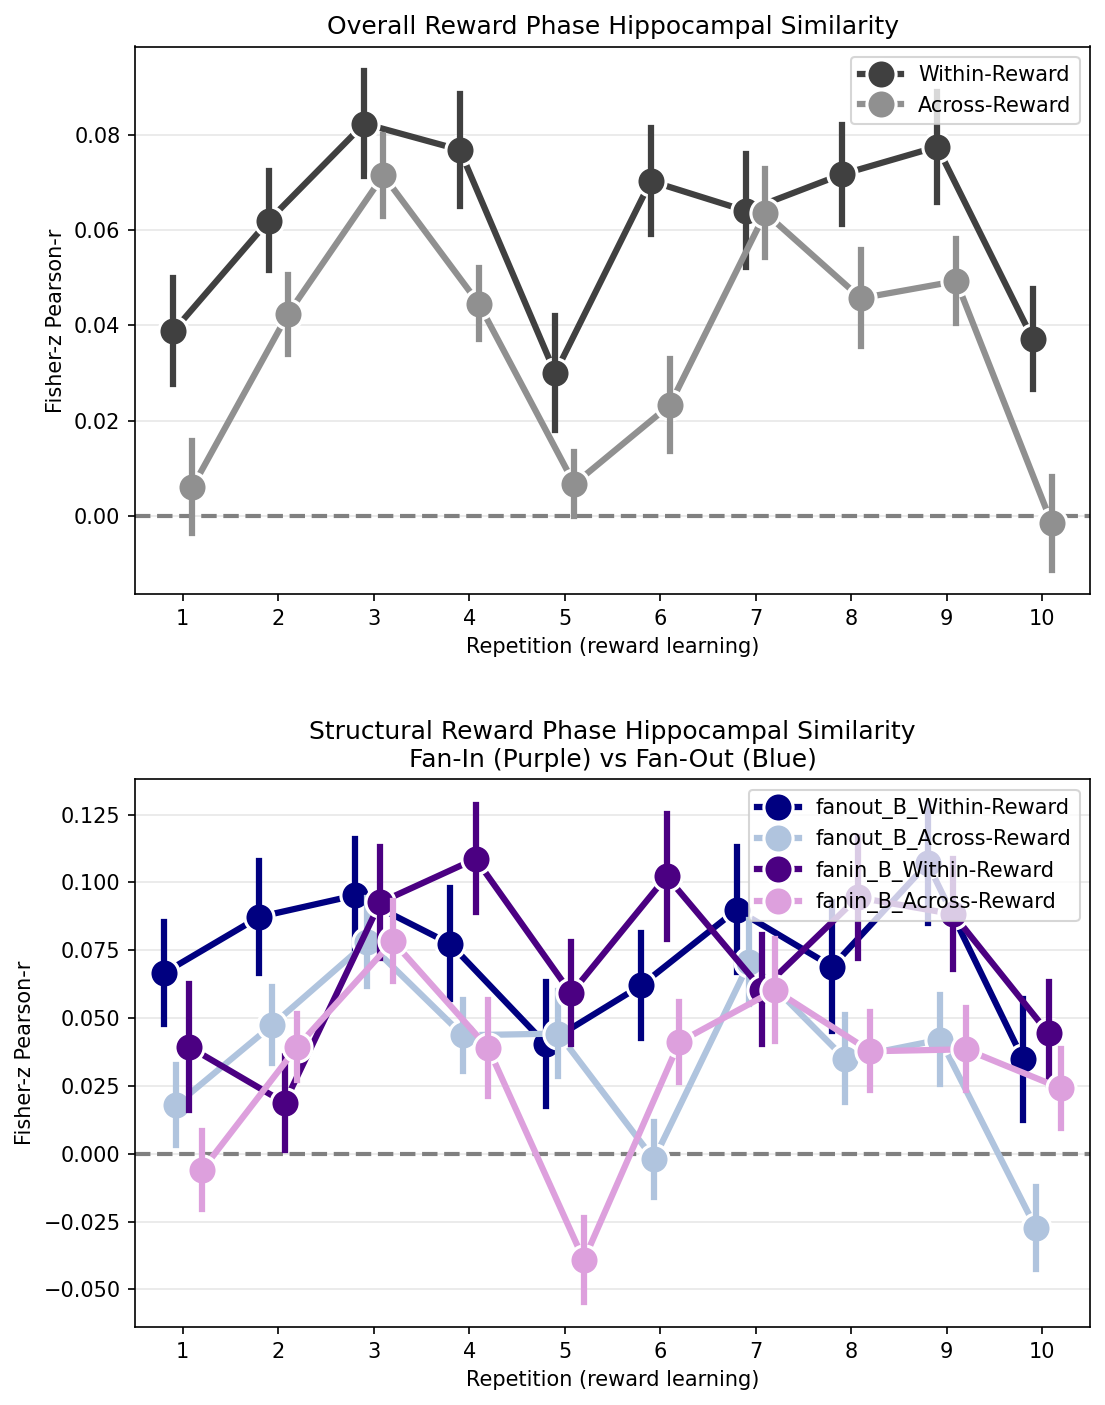

In [ ]:
# get similarity of B$ to B0 
# PLOT 1: 3 lines
# -avg B$ to B0 similarity
# -avg B$ to B$ similarity
# -avg B0 to B0 similarity
# PLOT 2: same but split into fan-in (purple) and fan-out (blue)

# Helper Plot Function (Modified to accept ax target)
def construct_similarity_ax(ax, df, conditions, palette, title, ylabel="Fisher-z Pearson-r"):
    ax.set_title(title)
    ax.set_xlabel("Repetition (reward learning)")
    ax.set_ylabel(ylabel)
    ax.hlines(0, xmin=-0.5, xmax=9.5, color='gray', linestyle='--', linewidth=2) 
    
    plot_df = df[df.condition.isin(conditions)]
    sns.pointplot(
        ax=ax, data=plot_df, x='repetition', y='mean_corr',
        hue='condition', hue_order=conditions, 
        errorbar='se', dodge=0.1 * len(plot_df.condition.unique()),
        linewidth=3, markersize=14, markeredgecolor='white', 
        markeredgewidth=1.5, err_kws={'linewidth': 3}, palette=palette
    )
    ax.legend(loc='upper right', frameon=True, fontsize=10) 
    ax.grid(axis='y', alpha=0.3)
    return ax


# ==============================================================================
# 1. GENERATE REPRESENTATION DATA 
# ==============================================================================
hipp_data = load_all_hipp_data(task='rew')
all_sims = []

for sub_id, betas in hipp_data.items():
    sub_str = f"sub-{sub_id:02d}"
    df = get_raw_rew_beh(sub_id)
    if df.empty: continue
    
    item_to_reward = {}
    item_to_cond = {}
    
    for i in range(len(df) - 1):
        trial_type = df.loc[i, 'trial_type']
        if trial_type not in ['reward', 'no_reward']:
            cond = 'fanin_B' if df.loc[i, 'paired_type2'] != 'none' else 'fanout_B'
            item_to_cond[trial_type] = cond
            next_trial = df.loc[i+1, 'trial_type']
            item_to_reward[trial_type] = 'Rew' if next_trial == 'reward' else 'Unrew'
                
    stims = df[~df['trial_type'].isin(['reward', 'no_reward'])].copy().reset_index(drop=True)
    stims['rep'] = stims.groupby('trial_type').cumcount() + 1
    
    # Precompute full correlation matrix
    r_matrix = np.corrcoef(betas, rowvar=True)
    r_matrix = np.clip(r_matrix, -0.999, 0.999) 
    z_matrix = np.arctanh(r_matrix)
    
    for rep in range(1, 11):
        rep_df = stims[stims['rep'] == rep]
        
        for i in range(len(rep_df)):
            for j in range(i + 1, len(rep_df)):
                idx1, idx2 = rep_df.index[i], rep_df.index[j]
                item1, item2 = rep_df.iloc[i]['trial_type'], rep_df.iloc[j]['trial_type']
                
                rew1, rew2 = item_to_reward.get(item1), item_to_reward.get(item2)
                cond1, cond2 = item_to_cond.get(item1), item_to_cond.get(item2)
                
                # Pool strictly into WITHIN or ACROSS fate
                if rew1 == rew2:
                    pair_type = 'Within-Reward'
                else: 
                    pair_type = 'Across-Reward'
                
                cond_pair = f"{cond1}_{pair_type}" if cond1 == cond2 else "mixed"
                
                z = z_matrix[idx1, idx2]
                if np.isnan(z): continue 
                    
                all_sims.append({
                    'sub': sub_str, 'repetition': rep,
                    'pair_type': pair_type, 'cond_pair': cond_pair, 'z_corr': z
                })

sim_df = pd.DataFrame(all_sims)
sub_avg = sim_df.groupby(['sub', 'repetition', 'pair_type', 'cond_pair'])['z_corr'].mean().reset_index()


# ==============================================================================
# 2. RENDER THE COMBINED SUBPLOTS (Vertically Stacked)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), dpi=150)

# PANEL 1 (Grayscale)
overall_avg = sub_avg.groupby(['sub', 'repetition', 'pair_type'])['z_corr'].mean().reset_index()
overall_avg.rename(columns={'pair_type': 'condition', 'z_corr': 'mean_corr'}, inplace=True)

conds_overall = ['Within-Reward', 'Across-Reward']
palette_overall = {'Within-Reward': '#404040', 'Across-Reward': '#909090'}

construct_similarity_ax(
    ax=ax1, df=overall_avg, conditions=conds_overall, palette=palette_overall, 
    title="Overall Reward Phase Hippocampal Similarity"
)

# PANEL 2 (Blues & Purples)
split_avg = sub_avg[sub_avg['cond_pair'] != 'mixed'].copy()
split_avg.rename(columns={'cond_pair': 'condition', 'z_corr': 'mean_corr'}, inplace=True)

conds_split = [
    'fanout_B_Within-Reward', 'fanout_B_Across-Reward',
    'fanin_B_Within-Reward',  'fanin_B_Across-Reward'
]
palette_split = {
    'fanout_B_Within-Reward': 'navy', 
    'fanout_B_Across-Reward': 'lightsteelblue',
    'fanin_B_Within-Reward':  'indigo', 
    'fanin_B_Across-Reward':  'plum'
}

construct_similarity_ax(
    ax=ax2, df=split_avg, conditions=conds_split, palette=palette_split, 
    title="Structural Reward Phase Hippocampal Similarity\nFan-In (Purple) vs Fan-Out (Blue)"
)

plt.tight_layout(pad=3.0)
plt.savefig('plots/plot_similarity_reward_phase.png', bbox_inches='tight')
plt.show()



# Other

autocorrelation

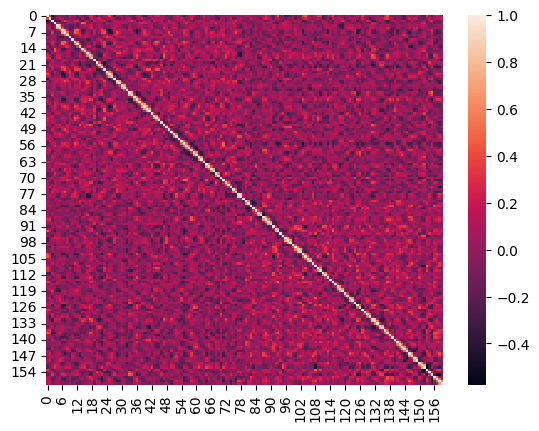

In [93]:
import seaborn as sns
data = hipp_patterns[29]
corr_mat = np.corrcoef(data)
sns.heatmap(corr_mat)
plt.show()

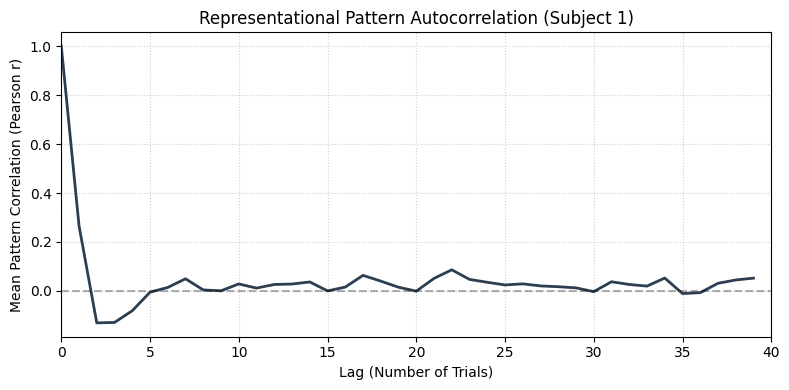

In [95]:
data = hipp_patterns[1][:80]
corr_mat = np.corrcoef(data)
n_trials = corr_mat.shape[0]
lags = np.arange(40)
acf = [np.mean(np.diag(corr_mat, k=lag)) for lag in lags]

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(lags, acf, linewidth=2, color='#2c3e50')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Lag (Number of Trials)')
plt.ylabel('Mean Pattern Correlation (Pearson r)')
plt.title('Representational Pattern Autocorrelation (Subject 1)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 40) 
plt.tight_layout()
plt.show()


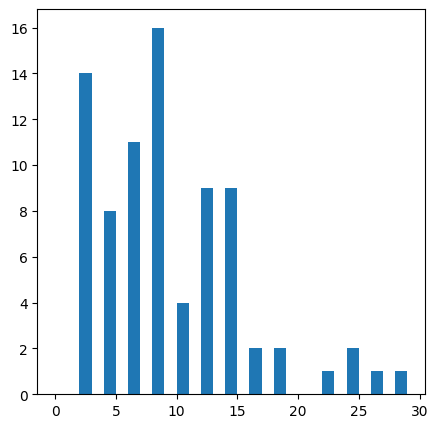

Minimum distance found: 2 trials
Maximum distance found: 28 trials
Proportion within 5 trials: 27.50%


In [96]:

beh = get_beh_data(4)
def get_pair_distances(beh):
    distances = []
    for idx, row in beh.iterrows():
        if not pd.isna(row.pair_to_compare):
            # Get indices of all trials where the partner stimulus appeared
            partner_indices = beh.index[beh.trial_type == row.pair_to_compare].values
            # Calculate the trial lag to the NEAREST partner appearance (before or after)
            min_dist = np.min(np.abs(partner_indices - idx))
            # if min_dist ==2:
            #     print(idx)
            distances.append(min_dist)
    return np.array(distances)

dists = get_pair_distances(beh)

plt.figure(figsize=(5, 5), dpi=100)
plt.hist(dists, bins=np.arange(30))
plt.show()
print(f"Minimum distance found: {dists.min()} trials")
print(f"Maximum distance found: {dists.max()} trials")

# Proportion of pair occurrences within 5 trials (distance <= 5)
prop_within_5 = np.mean(dists <= 5)
print(f"Proportion within 5 trials: {prop_within_5:.2%}")
